# Task 7 

The problem: if I just threshold the coins image, the ones that are touching merge into
one big white blob. So counting connected regions gives the wrong number.

Watershed fixes this. The idea is to treat the image like terrain and flood it from
marked starting points, then build walls wherever two floods meet. Those walls become
the boundaries between touching coins.

The important bit is the distance transform. For every white pixel it measures how far
away the nearest black pixel is. The middle of a coin is far from any edge so it scores
high; where two coins touch you're close to background on both sides so it scores low.
Threshold that and you get one separate blob per coin, which becomes the markers.

Note: I used THRESH_BINARY_INV here because the coins are darker than the background,
and watershed needs the coins to be the white foreground.

Parameters:
* Otsu for the threshold (no manual value)
* 3x3 kernel, opening with 2 iterations for noise removal
* Dilation with 3 iterations for sure background
* Distance transform threshold at 0.7 times the max

Coins detected: 24


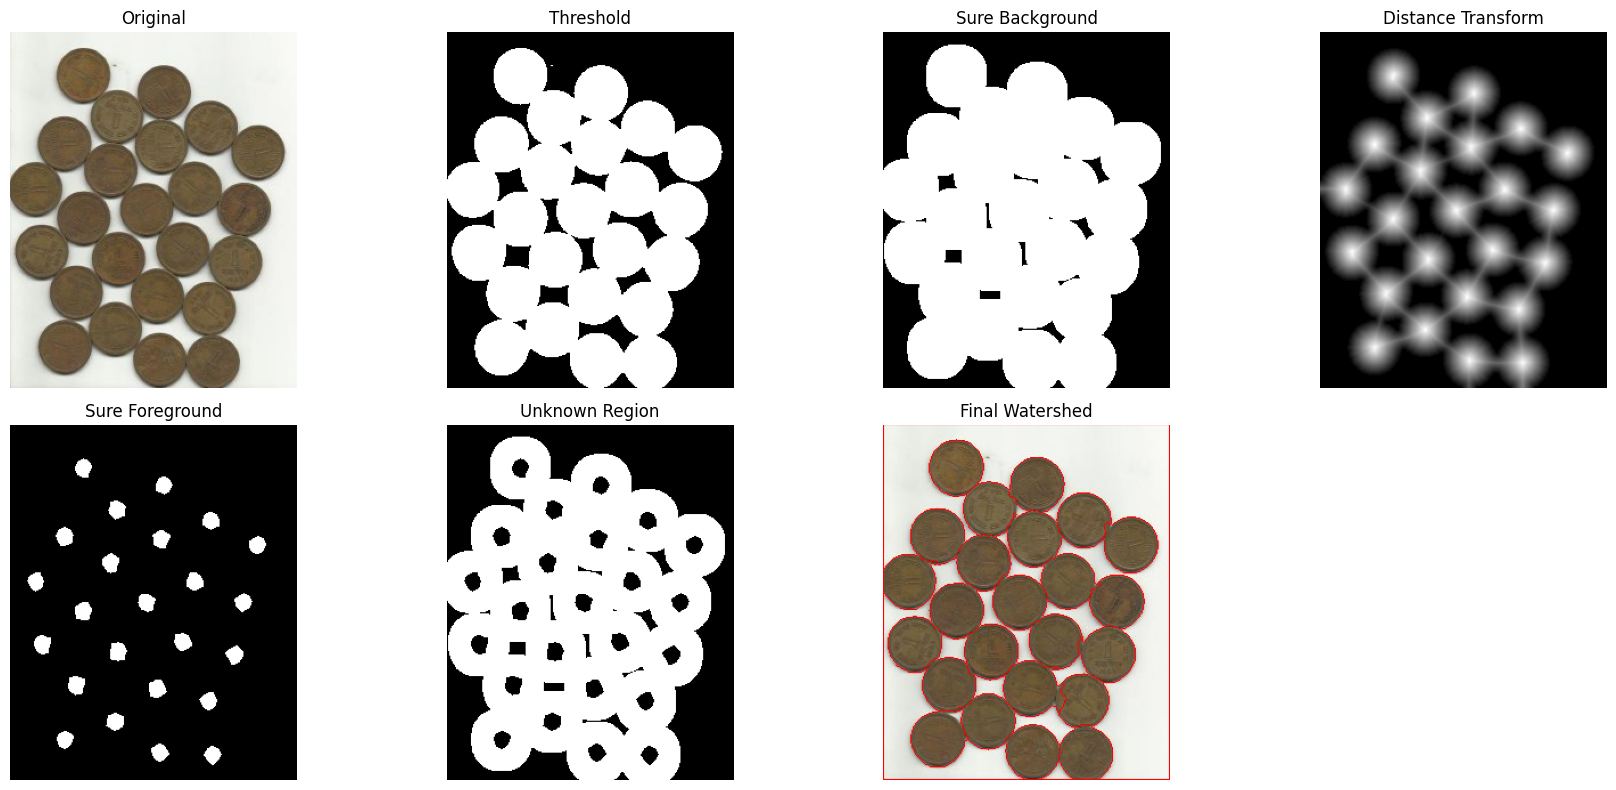

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("water_coins.jpg")

if img is None:
    print("Error: water_coins.jpg not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1-2. Threshold (INV so coins become white foreground)
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Noise removal
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # 4. Sure background: dilate so the coins spread outward
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 5. Distance transform: bright at coin centres
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # 6. Sure foreground: keep only the bright centres
    _, sure_fg = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # 7. Unknown region: the edges we are unsure about
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 8. Label each sure-foreground blob with its own number
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1              # background becomes 1, not 0
    markers[unknown == 255] = 0        # unknown area marked as 0

    print("Coins detected:", markers.max() - 1)

    # 9. Watershed
    markers = cv2.watershed(img, markers)

    # 10. Draw the boundaries in red
    result = img.copy()
    result[markers == -1] = [0, 0, 255]

    titles = ["Original", "Threshold", "Sure Background",
              "Distance Transform", "Sure Foreground",
              "Unknown Region", "Final Watershed"]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), thresh, sure_bg,
              dist, sure_fg, unknown,
              cv2.cvtColor(result, cv2.COLOR_BGR2RGB)]

    plt.figure(figsize=(18, 8))
    for i in range(7):
        plt.subplot(2, 4, i + 1)
        if i == 0 or i == 6:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

The distance transform panel is the interesting one. Each coin shows up as a bright spot
in its centre, and there are dark gaps where coins touch. Those gaps are what lets
watershed split them apart.

**How the stages fit together**

The sure background comes from dilating the coins outward, so anything black in that
panel is definitely not a coin. The sure foreground comes from the distance transform, so
those bright blobs are definitely inside a coin. Subtracting one from the other gives the
unknown region, which is the band around each coin's edge where the real boundary is
somewhere.

Watershed only has to figure out that unknown band, since everything else is already
decided.

**Did it work?**

Looking at the final panel with the red boundaries, the touching coins have been
separated properly. Each coin gets its own outline instead of the merged blob I'd get
from just thresholding.

Coins detected is printed above; that number comes from the markers, which is why Task 8
looks at how the distance threshold changes it.